# OAI Full-Limb Cohort — Split by Coronal Deformity (varus / normal / valgus)

Companion to `hto_correction_angles_oai_external_validation.ipynb`. Partitions the OAI
full-limb cohort into three **subsets of copies** — varus, normal (neutral), valgus — so
external validation can be reported per deformity stratum instead of pooled.

**Labels come from OAI's clinical HKA**, not from the model: `hka_side1` / `hka_side2` in
`oai_hka_groundtruth.csv` (built by `scripts/prepare_oai_hka.py`). Keeping the strata
model-independent is the point — a split defined by predicted HKA would put the model's own
errors into the group definitions and flatter the per-stratum numbers.

**Class rule** (OAISYS convention: signed, 0 = neutral, negative = varus):

| class  | condition               |
|--------|-------------------------|
| varus  | `HKA < -NEUTRAL_BAND`   |
| normal | `|HKA| <= NEUTRAL_BAND` |
| valgus | `HKA > +NEUTRAL_BAND`   |

`NEUTRAL_BAND = 3.0°`, matching the stratification already used in the validation notebook.

**Bilateral images.** A full-limb radiograph carries two knees that need not share a class.
Each image is therefore copied into **every class present in it** — a varus-left / valgus-right
limb film lands in both subsets — and the per-subset ground-truth CSV **blanks the knee that
doesn't belong to that stratum**, so downstream metrics only ever see qualifying knees. No
knee is dropped and none is counted twice within a stratum.

**Non-destructive.** Source images are only ever read: files are written into a fresh
`OUT_ROOT`, never renamed, moved or deleted in `OAI_IMAGE_DIR`. The final cell verifies the
source directory is byte-identical to how it started.

**Outputs**

```
OUT_ROOT/
  varus/   <barcode>.dcm ...   oai_hka_groundtruth.csv
  normal/  <barcode>.dcm ...   oai_hka_groundtruth.csv
  valgus/  <barcode>.dcm ...   oai_hka_groundtruth.csv
  knee_manifest.csv     one row per knee   (barcode, side, hka, class, subsets)
  image_manifest.csv    one row per image  (barcode, classes present, copies made)
  hka_distribution.png
```

Each subset directory is a drop-in target for the validation notebook: point
`OAI_IMAGE_DIR` and `OAI_HKA_CSV` at it and run unchanged.

## Configuration — edit these

In [1]:
# ============================================================================
# Split config  —  mirrors the paths used by the external-validation notebook
# ============================================================================
OAI_IMAGE_DIR = "/tf/data/hka/oai_dicoms"                # source <barcode>.dcm files (READ ONLY)
OAI_HKA_CSV   = "/tf/data/hka/oai_hka_groundtruth.csv"   # HKA ground truth
OUT_ROOT      = "/tf/data/hka/oai_by_deformity"          # subsets are created here

HKA_KEY_COL   = "barcode"        # == image filename stem
HKA_SIDE1_COL = "hka_side1"
HKA_SIDE2_COL = "hka_side2"

# OAISYS convention: signed, 0 = neutral, negative = varus.
# Set True only if your CSV stores HKA as an absolute angle with 180 = straight leg.
HKA_NEUTRAL_180 = False
NEUTRAL_BAND    = 3.0            # deg; |HKA - neutral| <= band => normal

CLASSES     = ("varus", "normal", "valgus")
SUBSET_DIRS = {c: c for c in CLASSES}          # class -> folder name under OUT_ROOT

# "copy"     real independent copies (safe default; ~1x disk of the source set)
# "hardlink" same bytes on disk, no extra space  — same filesystem only, edits alias
# "symlink"  pointers only, no extra space       — breaks if the source moves
COPY_MODE   = "copy"
OVERWRITE   = False              # re-copy files already present in the destination
MASK_NONMEMBER_SIDES = True      # blank the off-class knee in each subset CSV

IMG_EXTS = (".dcm", ".dicom", ".png", ".jpg", ".jpeg", ".tif", ".tiff")

NEUTRAL = 180.0 if HKA_NEUTRAL_180 else 0.0
assert COPY_MODE in ("copy", "hardlink", "symlink"), COPY_MODE
print(f"Classes: varus < {NEUTRAL - NEUTRAL_BAND:.1f} | "
      f"normal {NEUTRAL - NEUTRAL_BAND:.1f}..{NEUTRAL + NEUTRAL_BAND:.1f} | "
      f"valgus > {NEUTRAL + NEUTRAL_BAND:.1f}   (deg, neutral = {NEUTRAL:.0f})")
print(f"Mode: {COPY_MODE}  ->  {OUT_ROOT}")

Classes: varus < -3.0 | normal -3.0..3.0 | valgus > 3.0   (deg, neutral = 0)
Mode: copy  ->  /tf/data/hka/oai_by_deformity


## Load Ground Truth & Index the Source Images

In [2]:
import os
import glob
import shutil
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- ground truth: one row per full-limb image (barcode) ----
hka_df = pd.read_csv(OAI_HKA_CSV, dtype={HKA_KEY_COL: str})
hka_df[HKA_KEY_COL] = hka_df[HKA_KEY_COL].str.strip()
if hka_df[HKA_KEY_COL].duplicated().any():
    n_dup = int(hka_df[HKA_KEY_COL].duplicated().sum())
    hka_df = hka_df.drop_duplicates(HKA_KEY_COL, keep="first").reset_index(drop=True)
    print(f"WARNING: dropped {n_dup} duplicate barcode row(s), kept first.")

for col in (HKA_SIDE1_COL, HKA_SIDE2_COL):
    hka_df[col] = pd.to_numeric(hka_df[col], errors="coerce")

# ---- source images, indexed by filename stem (== barcode) ----
src_paths = sorted(p for p in glob.glob(os.path.join(OAI_IMAGE_DIR, "*"))
                   if os.path.splitext(p)[1].lower() in IMG_EXTS)
src_index = {}
for p in src_paths:
    src_index.setdefault(os.path.splitext(os.path.basename(p))[0], p)

n_knees = int(hka_df[[HKA_SIDE1_COL, HKA_SIDE2_COL]].notna().sum().sum())
present  = hka_df[HKA_KEY_COL].isin(src_index).sum()
print(f"Ground truth : {len(hka_df)} images / {n_knees} knees with HKA")
print(f"Source images: {len(src_paths)} files in {OAI_IMAGE_DIR}")
print(f"Matched      : {present} images have both a file and ground truth "
      f"({len(hka_df) - present} rows without an image, "
      f"{len(src_index) - present} images without ground truth)")

Ground truth : 3831 images / 7647 knees with HKA
Source images: 3831 files in /tf/data/hka/oai_dicoms
Matched      : 3831 images have both a file and ground truth (0 rows without an image, 0 images without ground truth)


## Classify Every Knee

One row per knee. `side` follows the OAI column it came from (`hka_side1` -> `"1"`), which is
the same key the validation notebook matches on via `IMAGE_LEFT_IS_SIDE`.

In [3]:
def classify(hka):
    """Signed HKA -> 'varus' | 'normal' | 'valgus' (None if missing)."""
    if hka is None or (isinstance(hka, float) and np.isnan(hka)) or pd.isna(hka):
        return None
    dev = float(hka) - NEUTRAL
    if dev < -NEUTRAL_BAND:
        return "varus"
    if dev > NEUTRAL_BAND:
        return "valgus"
    return "normal"

# quick self-test of the boundaries (inclusive neutral band)
_neutral_examples = [NEUTRAL - NEUTRAL_BAND, NEUTRAL, NEUTRAL + NEUTRAL_BAND]
assert [classify(v) for v in _neutral_examples] == ["normal"] * 3
assert classify(NEUTRAL - NEUTRAL_BAND - 0.01) == "varus"
assert classify(NEUTRAL + NEUTRAL_BAND + 0.01) == "valgus"
assert classify(np.nan) is None
print("classify() self-test passed.")

# ---- per-knee manifest ----
knee_rows = []
for _, r in hka_df.iterrows():
    bc = r[HKA_KEY_COL]
    for side, col in (("1", HKA_SIDE1_COL), ("2", HKA_SIDE2_COL)):
        cls = classify(r[col])
        if cls is None:
            continue
        knee_rows.append(dict(
            barcode=bc, side=side, hka=float(r[col]), deformity=cls,
            has_image=bc in src_index,
            subj=r.get("subj"), visit=r.get("visit"),
            sex=r.get("sex"), ageyears=r.get("ageyears"),
        ))
knee_manifest = pd.DataFrame(knee_rows)

# ---- per-image manifest: the set of classes present in each image ----
img_rows = []
for bc, g in knee_manifest.groupby("barcode", sort=True):
    classes = sorted(set(g["deformity"]), key=CLASSES.index)
    img_rows.append(dict(
        barcode=bc, n_knees=len(g), classes="|".join(classes), n_subsets=len(classes),
        hka_side1=float(g.loc[g["side"] == "1", "hka"].iloc[0]) if (g["side"] == "1").any() else np.nan,
        hka_side2=float(g.loc[g["side"] == "2", "hka"].iloc[0]) if (g["side"] == "2").any() else np.nan,
        has_image=bool(g["has_image"].iloc[0]),
    ))
image_manifest = pd.DataFrame(img_rows)

assert len(knee_manifest) == n_knees, "knee count drifted from the ground-truth table"
print(f"Classified {len(knee_manifest)} knees across {len(image_manifest)} images.")
print(f"Images spanning two classes (copied into both): "
      f"{int((image_manifest['n_subsets'] > 1).sum())}")
knee_manifest.head()

classify() self-test passed.
Classified 7647 knees across 3831 images.
Images spanning two classes (copied into both): 1264


,barcode,side,hka,deformity,has_image,subj,visit,sex,ageyears
0,16600375104,1,0.150000,normal,True,9454100,V01,F,59
1,16600375104,2,2.436667,normal,True,9454100,V01,F,59
2,16600376806,1,-5.865000,varus,True,9774237,V03,F,72
3,16600376806,2,-1.780000,normal,True,9774237,V03,F,72
4,16600756404,1,3.553333,valgus,True,9566704,V01,F,60


## Summary & HKA Distribution

OAI COHORT BY CORONAL DEFORMITY  (neutral band ±3.0°)
  varus   knees= 2155 ( 28.2%)  images= 1519  HKA  -5.26 ± 2.01°  [ -16.6,   -3.0]
  normal  knees= 4822 ( 63.1%)  images= 3034  HKA  -0.31 ± 1.62°  [  -3.0,   +3.0]
  valgus  knees=  670 (  8.8%)  images=  542  HKA  +5.00 ± 2.05°  [  +3.0,  +18.9]
  TOTAL   knees= 7647          images= 3831  HKA  -1.24 ± 3.42°


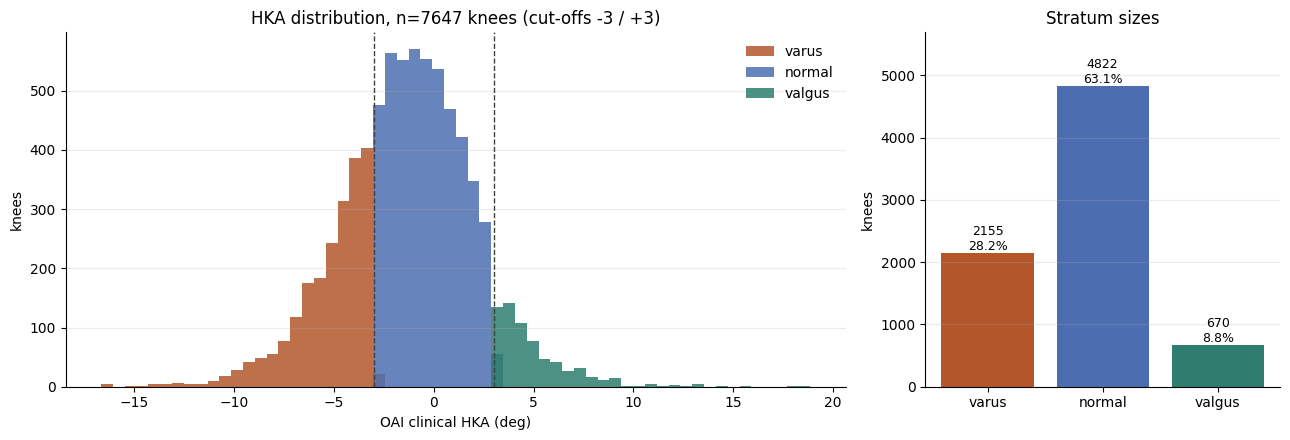

,deformity,knees,knees_with_image,images,hka_mean,hka_sd,hka_min,hka_max,knees_pct
0,varus,2155,2155,1519,-5.263243,2.008750,-16.65,-3.005,28.180986
1,normal,4822,4822,3034,-0.307574,1.618373,-3.00,3.000,63.057408
2,valgus,670,670,542,4.996095,2.053005,3.01,18.860,8.761606


In [4]:
# ---- counts and per-stratum HKA statistics ----
avail = knee_manifest[knee_manifest["has_image"]]
summary = pd.DataFrame([
    dict(deformity=c,
         knees=int((knee_manifest["deformity"] == c).sum()),
         knees_with_image=int((avail["deformity"] == c).sum()),
         images=int(image_manifest["classes"].str.split("|").apply(lambda s, c=c: c in s).sum()),
         hka_mean=knee_manifest.loc[knee_manifest["deformity"] == c, "hka"].mean(),
         hka_sd=knee_manifest.loc[knee_manifest["deformity"] == c, "hka"].std(ddof=1),
         hka_min=knee_manifest.loc[knee_manifest["deformity"] == c, "hka"].min(),
         hka_max=knee_manifest.loc[knee_manifest["deformity"] == c, "hka"].max())
    for c in CLASSES
])
summary["knees_pct"] = 100 * summary["knees"] / max(len(knee_manifest), 1)

print("=" * 72)
print(f"OAI COHORT BY CORONAL DEFORMITY  (neutral band ±{NEUTRAL_BAND:.1f}°)")
print("=" * 72)
for _, s in summary.iterrows():
    print(f"  {s['deformity']:7s} knees={s['knees']:5d} ({s['knees_pct']:5.1f}%)  "
          f"images={s['images']:5d}  HKA {s['hka_mean']:+6.2f} ± {s['hka_sd']:4.2f}°  "
          f"[{s['hka_min']:+6.1f}, {s['hka_max']:+6.1f}]")
print(f"  {'TOTAL':7s} knees={len(knee_manifest):5d}          "
      f"images={len(image_manifest):5d}  HKA {knee_manifest['hka'].mean():+6.2f} "
      f"± {knee_manifest['hka'].std(ddof=1):4.2f}°")

# ---- distribution with the cut-offs marked ----
PALETTE = {"varus": "#B3572B", "normal": "#4C6EB1", "valgus": "#2E7D6F"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5),
                               gridspec_kw={"width_ratios": [2.2, 1]})

bins = np.histogram_bin_edges(knee_manifest["hka"].values, bins=60)
for c in CLASSES:
    ax1.hist(knee_manifest.loc[knee_manifest["deformity"] == c, "hka"].values,
             bins=bins, color=PALETTE[c], alpha=0.85, label=c)
for cut in (NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND):
    ax1.axvline(cut, color="0.25", ls="--", lw=1)
ax1.set_xlabel("OAI clinical HKA (deg)")
ax1.set_ylabel("knees")
ax1.set_title(f"HKA distribution, n={len(knee_manifest)} knees "
              f"(cut-offs {NEUTRAL - NEUTRAL_BAND:+.0f} / {NEUTRAL + NEUTRAL_BAND:+.0f})")
ax1.legend(frameon=False)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", alpha=0.25)

ax2.bar(summary["deformity"], summary["knees"],
        color=[PALETTE[c] for c in summary["deformity"]])
for i, (v, p) in enumerate(zip(summary["knees"], summary["knees_pct"])):
    ax2.text(i, v, f"{int(v)}\n{p:.1f}%", ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("knees")
ax2.set_title("Stratum sizes")
ax2.set_ylim(0, summary["knees"].max() * 1.18)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", alpha=0.25)

plt.tight_layout()
os.makedirs(OUT_ROOT, exist_ok=True)
plt.savefig(os.path.join(OUT_ROOT, "hka_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
summary

## Copy Images Into the Subsets

Copies only — the source directory is never written to. Existing destination files are left
alone unless `OVERWRITE = True`, so the cell is safe to re-run after an interruption.

In [5]:
# ---- snapshot the source directory so the final cell can prove it is untouched ----
def dir_fingerprint(d, exts=IMG_EXTS):
    out = {}
    for p in glob.glob(os.path.join(d, "*")):
        if os.path.splitext(p)[1].lower() in exts and os.path.isfile(p):
            st = os.stat(p)
            out[os.path.basename(p)] = (st.st_size, int(st.st_mtime))
    return out

SRC_FINGERPRINT_BEFORE = dir_fingerprint(OAI_IMAGE_DIR)
print(f"Source fingerprint: {len(SRC_FINGERPRINT_BEFORE)} files recorded.")

def place(src, dst, mode=None):
    """Materialise *src* at *dst* without touching *src*. Returns 'written' | 'skipped'."""
    mode = mode or COPY_MODE
    if os.path.exists(dst) or os.path.islink(dst):
        if not OVERWRITE:
            return "skipped"
        os.remove(dst)
    tmp = dst + ".part"
    if mode == "copy":
        shutil.copy2(src, tmp)          # copy2 preserves mtime; source opened read-only
    elif mode == "hardlink":
        os.link(src, tmp)
    else:
        os.symlink(os.path.abspath(src), tmp)
    os.replace(tmp, dst)
    return "written"


for c in CLASSES:
    os.makedirs(os.path.join(OUT_ROOT, SUBSET_DIRS[c]), exist_ok=True)

try:
    from tqdm.auto import tqdm
except Exception:                                    # tqdm optional
    def tqdm(x, **kw): return x

copy_rows, n_written, n_skipped, n_missing = [], 0, 0, 0
work = [(r["barcode"], cls) for _, r in image_manifest.iterrows()
        for cls in r["classes"].split("|")]

for bc, cls in tqdm(work, desc="copying", unit="file"):
    src = src_index.get(bc)
    if src is None:
        n_missing += 1
        copy_rows.append(dict(barcode=bc, deformity=cls, src=None, dst=None, status="no_image"))
        continue
    dst = os.path.join(OUT_ROOT, SUBSET_DIRS[cls], os.path.basename(src))
    try:
        status = place(src, dst)
    except Exception as e:
        status = f"error:{type(e).__name__}"
    n_written += (status == "written")
    n_skipped += (status == "skipped")
    copy_rows.append(dict(barcode=bc, deformity=cls, src=src, dst=dst, status=status))

copy_log = pd.DataFrame(copy_rows)
print(f"\nplanned {len(work)} placements: {n_written} written, {n_skipped} already present, "
      f"{n_missing} skipped (no image file).")
errs = copy_log[copy_log["status"].str.startswith("error")]
if len(errs):
    print(f"ERRORS: {len(errs)}"); display(errs.head(10))

Source fingerprint: 3831 files recorded.


copying:   0%|          | 0/5095 [00:00<?, ?file/s]


planned 5095 placements: 5095 written, 0 already present, 0 skipped (no image file).


## Per-Subset Ground Truth & Manifests

Each subset gets an `oai_hka_groundtruth.csv` with the **same schema as the source table**, so
the validation notebook runs against a subset unchanged — just repoint `OAI_IMAGE_DIR` and
`OAI_HKA_CSV`. With `MASK_NONMEMBER_SIDES = True` the off-class knee of a mixed image is
blanked (`hka`, `nread`, `readsd`), and the validation loop skips NaN sides on its own.

In [6]:
written_csvs = {}
for c in CLASSES:
    members = knee_manifest[knee_manifest["deformity"] == c]
    sub = hka_df[hka_df[HKA_KEY_COL].isin(set(members["barcode"]))].copy()

    if MASK_NONMEMBER_SIDES:
        keep = {(b, s) for b, s in zip(members["barcode"], members["side"])}
        for side, hcol in (("1", HKA_SIDE1_COL), ("2", HKA_SIDE2_COL)):
            off = ~sub[HKA_KEY_COL].map(lambda b, s=side: (b, s) in keep)
            for col in (hcol, f"nread_side{side}", f"readsd_side{side}"):
                if col in sub.columns:
                    sub.loc[off, col] = np.nan

    path = os.path.join(OUT_ROOT, SUBSET_DIRS[c], "oai_hka_groundtruth.csv")
    sub.to_csv(path, index=False)
    written_csvs[c] = path
    n_kept = int(sub[[HKA_SIDE1_COL, HKA_SIDE2_COL]].notna().sum().sum())
    print(f"{c:7s} -> {path}   {len(sub):5d} images / {n_kept:5d} knees")

knee_path = os.path.join(OUT_ROOT, "knee_manifest.csv")
img_path  = os.path.join(OUT_ROOT, "image_manifest.csv")
log_path  = os.path.join(OUT_ROOT, "copy_log.csv")
knee_manifest.to_csv(knee_path, index=False)
image_manifest.to_csv(img_path, index=False)
copy_log.to_csv(log_path, index=False)
summary.to_csv(os.path.join(OUT_ROOT, "split_summary.csv"), index=False)
print(f"\nManifests: {knee_path}\n           {img_path}\n           {log_path}")

varus   -> /tf/data/hka/oai_by_deformity/varus/oai_hka_groundtruth.csv    1519 images /  2155 knees
normal  -> /tf/data/hka/oai_by_deformity/normal/oai_hka_groundtruth.csv    3034 images /  4822 knees
valgus  -> /tf/data/hka/oai_by_deformity/valgus/oai_hka_groundtruth.csv     542 images /   670 knees

Manifests: /tf/data/hka/oai_by_deformity/knee_manifest.csv
           /tf/data/hka/oai_by_deformity/image_manifest.csv
           /tf/data/hka/oai_by_deformity/copy_log.csv


## Verification

Fails loudly if anything is off: every knee assigned exactly once, subset CSVs consistent with
the manifests, the files actually on disk, copied bytes identical to the source, and — the one
that matters most — the source directory unchanged.

In [7]:
problems = []

# 1. every knee with an HKA got exactly one class; nothing invented, nothing lost
if len(knee_manifest) != n_knees:
    problems.append(f"knee count {len(knee_manifest)} != ground-truth knees {n_knees}")
if knee_manifest.duplicated(["barcode", "side"]).any():
    problems.append("duplicate (barcode, side) rows in the knee manifest")
if summary["knees"].sum() != len(knee_manifest):
    problems.append("stratum knee counts do not sum to the total")

# 2. class assignment agrees with the rule, recomputed from the raw CSV
recomputed = [classify(h) for h in knee_manifest["hka"]]
if recomputed != list(knee_manifest["deformity"]):
    problems.append("a class label disagrees with classify()")

# 3. files on disk match what the copy log says was placed
for c in CLASSES:
    d = os.path.join(OUT_ROOT, SUBSET_DIRS[c])
    on_disk = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(d, "*"))
               if os.path.splitext(p)[1].lower() in IMG_EXTS}
    expected = set(copy_log[(copy_log["deformity"] == c) &
                            (copy_log["status"].isin(["written", "skipped"]))]["barcode"])
    if on_disk != expected:
        problems.append(f"{c}: {len(expected - on_disk)} missing, "
                        f"{len(on_disk - expected)} unexpected file(s) on disk")

# 4. subset CSVs: knees retained == manifest count for that stratum (when masking)
for c in CLASSES:
    sub = pd.read_csv(written_csvs[c], dtype={HKA_KEY_COL: str})
    n_kept = int(sub[[HKA_SIDE1_COL, HKA_SIDE2_COL]].notna().sum().sum())
    n_expect = (int((knee_manifest["deformity"] == c).sum()) if MASK_NONMEMBER_SIDES
                else int(knee_manifest["barcode"].isin(set(sub[HKA_KEY_COL])).sum()))
    if n_kept != n_expect:
        problems.append(f"{c}: subset CSV holds {n_kept} knees, expected {n_expect}")
    if MASK_NONMEMBER_SIDES:
        kept_cls = {classify(v) for col in (HKA_SIDE1_COL, HKA_SIDE2_COL)
                    for v in pd.to_numeric(sub[col], errors="coerce").dropna()}
        if kept_cls - {c}:
            problems.append(f"{c}: subset CSV also retains {sorted(kept_cls - {c})} knees")

# 5. copied bytes identical to the source (checksum a random sample)
def md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

placed = copy_log[copy_log["status"].isin(["written", "skipped"])]
sample = placed.sample(min(12, len(placed)), random_state=0) if len(placed) else placed
for _, r in sample.iterrows():
    if not os.path.exists(r["dst"]):
        problems.append(f"missing copy {r['dst']}")
    elif md5(r["src"]) != md5(r["dst"]):
        problems.append(f"checksum mismatch: {r['dst']}")

# 6. the source directory is exactly as it was before the copy cell ran
after = dir_fingerprint(OAI_IMAGE_DIR)
if after != SRC_FINGERPRINT_BEFORE:
    gone    = set(SRC_FINGERPRINT_BEFORE) - set(after)
    added   = set(after) - set(SRC_FINGERPRINT_BEFORE)
    changed = {k for k in set(after) & set(SRC_FINGERPRINT_BEFORE)
               if after[k] != SRC_FINGERPRINT_BEFORE[k]}
    problems.append(f"SOURCE DIRECTORY CHANGED: {len(gone)} removed, "
                    f"{len(added)} added, {len(changed)} modified")

print("=" * 72)
if problems:
    print(f"VERIFICATION FAILED — {len(problems)} problem(s):")
    for p in problems:
        print("  ✗", p)
else:
    print("VERIFICATION PASSED")
    print(f"  {len(knee_manifest)} knees classified, {len(placed)} image copies placed")
    for c in CLASSES:
        print(f"  {c:7s} {os.path.join(OUT_ROOT, SUBSET_DIRS[c])}")
    print(f"  source directory unchanged ({len(SRC_FINGERPRINT_BEFORE)} files, "
          f"size + mtime identical)")
print("=" * 72)
assert not problems, problems

VERIFICATION PASSED
  7647 knees classified, 5095 image copies placed
  varus   /tf/data/hka/oai_by_deformity/varus
  normal  /tf/data/hka/oai_by_deformity/normal
  valgus  /tf/data/hka/oai_by_deformity/valgus
  source directory unchanged (3831 files, size + mtime identical)


## Using a Subset

In `hto_correction_angles_oai_external_validation.ipynb`, point the config cell at one stratum
and run top to bottom:

```python
OAI_IMAGE_DIR = "/tf/data/hka/oai_by_deformity/varus"
OAI_HKA_CSV   = "/tf/data/hka/oai_by_deformity/varus/oai_hka_groundtruth.csv"
```

Two notes when reporting per-stratum agreement:

- **Range restriction deflates ICC and r.** Within a stratum the HKA spread is much narrower
  than in the pooled cohort, so correlation-type statistics drop even when accuracy is
  identical. MAE, RMSE, bias and the limits of agreement stay interpretable — lead with those
  per stratum, and keep ICC for the pooled cohort.
- **Normal is the widest-populated but narrowest-ranged stratum**, so it is where the
  laterality/sign diagnostic is least informative. Confirm `IMAGE_LEFT_IS_SIDE` /
  `HKA_SIGN_FLIP` on the pooled set, or on varus, before trusting a per-stratum run.